Make sure the file is already downloaded - if not - download it now

In [13]:
import requests

url = "https://upload.wikimedia.org/wikipedia/commons/a/af/Golden_retriever_eating_pigs_foot.jpg"

headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)

if response.status_code == 200:
    with open("dog.jpg", "wb") as f:
        f.write(response.content)
    print("Image was saved as 'dog.jpg'")
else:
  print(f"Failed to download the file: status {response.status_code}")



Image was saved as 'dog.jpg'


Display the image

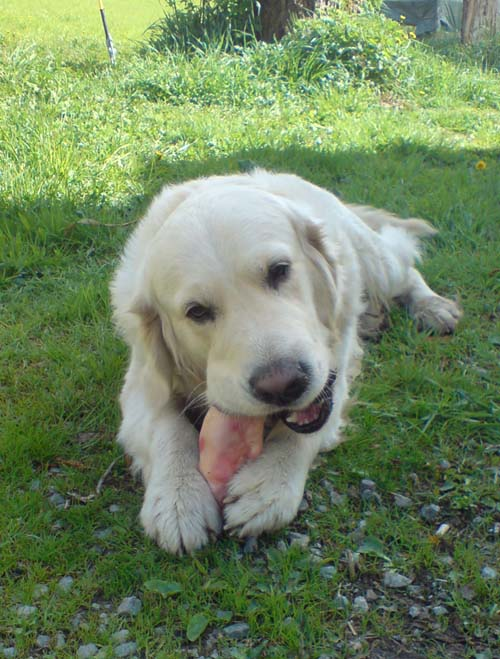

In [14]:
from PIL import Image
from IPython.display import display

img = Image.open("dog.jpg")
display(img)

Convert to grayscale

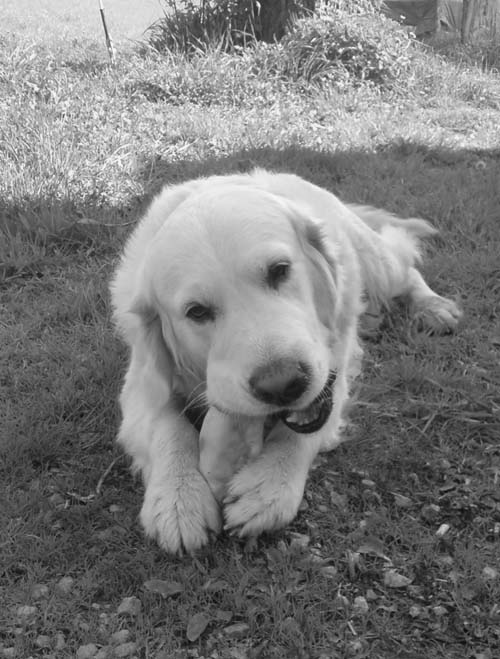

In [15]:
img_gray = img.convert("L")
img_gray

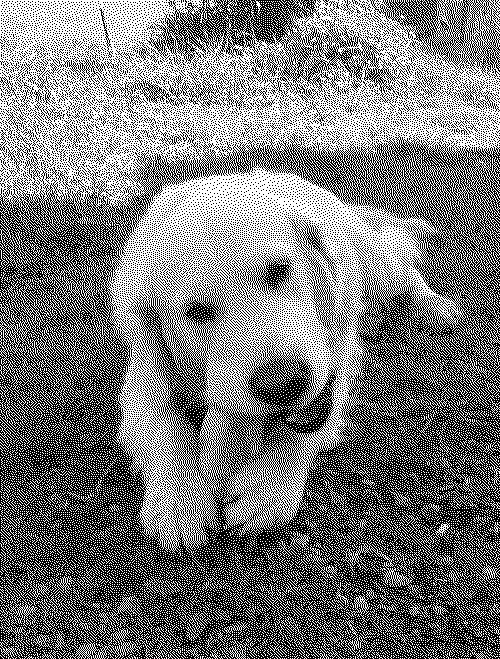

In [16]:
img_1 = img.convert("1")
img_1

| Feature | **RGB** | **RGBA** | **CMYK** |
| :--- | :--- | :--- | :--- |
| **Full Name** | Red, Green, Blue | Red, Green, Blue, Alpha | Cyan, Magenta, Yellow, Key (Black) |
| **Pixel Encoding** | 3 x 8-bit (24-bit total) | 4 x 8-bit (32-bit total) | 4 x 8-bit (32-bit total) |
| **Transparency** | No | **Yes** (Alpha channel) | No |
| **Typical Formats** | JPEG, PNG, BMP | **PNG**, WEBP, GIF | **TIFF**, JPEG (some), PDF |
| **Primary Use** | Web, Screens, Photography | UI Icons, Logos, Overlays | **Professional Printing** |
| **Color Mixing** | **Additive** (Light) | Additive + Transparency | **Subtractive** (Pigment) |
| **Conversion Note** | Default for most screens | Required for transparency | Colors may look dull on screens |

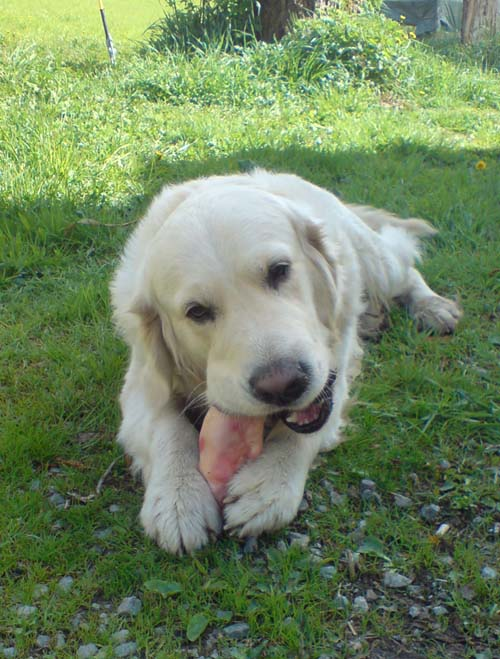

In [17]:
img_rgb = img.convert("RGB")
img_rgb

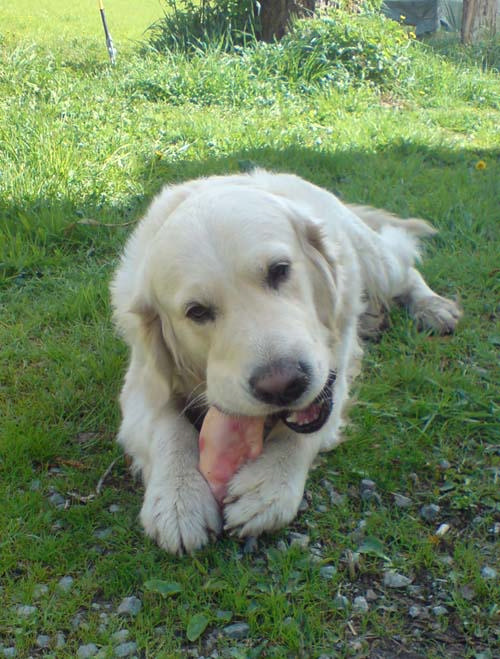

In [18]:
img_cmyk = img.convert("CMYK")
img_cmyk

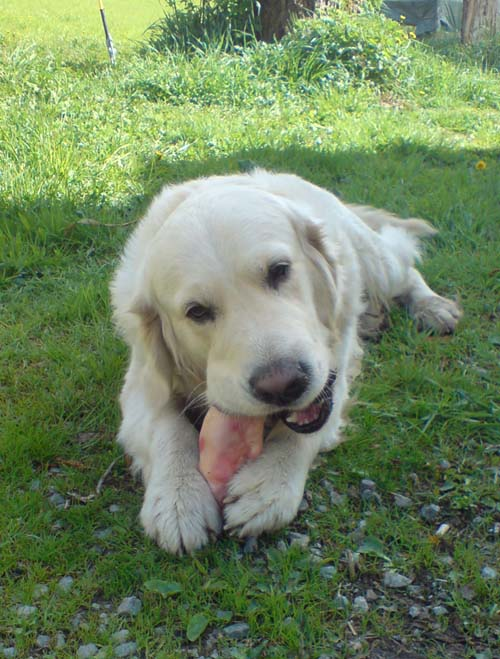

In [19]:
img_rgba = img.convert("RGBA")
img_rgba

Apply filters to image

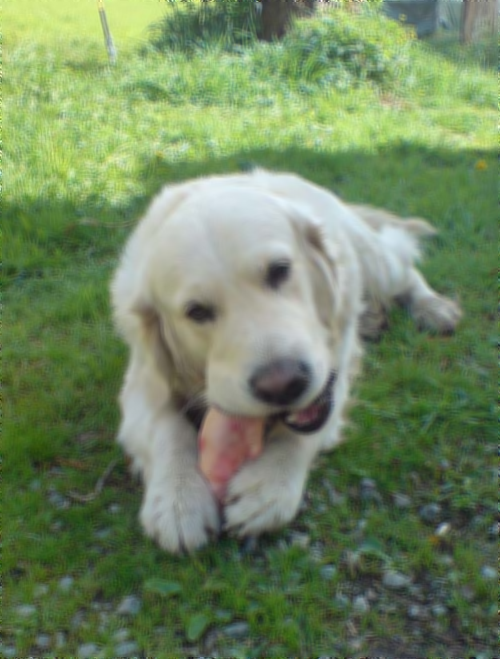

In [20]:
from PIL import ImageFilter

img_blur = img.filter(ImageFilter.BLUR)
img_blur

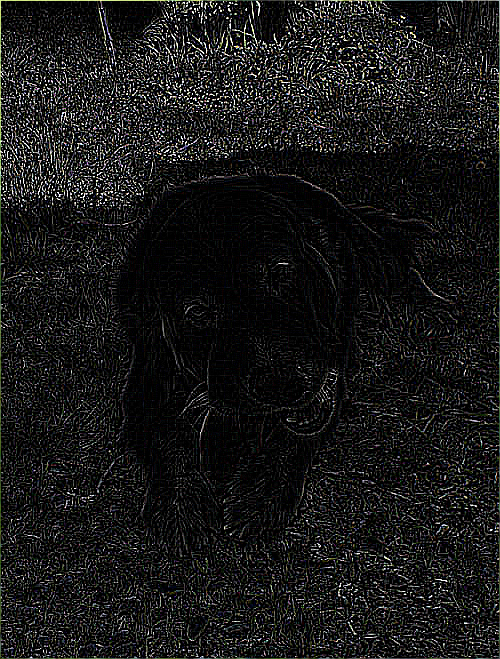

In [21]:
img_edges = img.filter(ImageFilter.FIND_EDGES)
img_edges

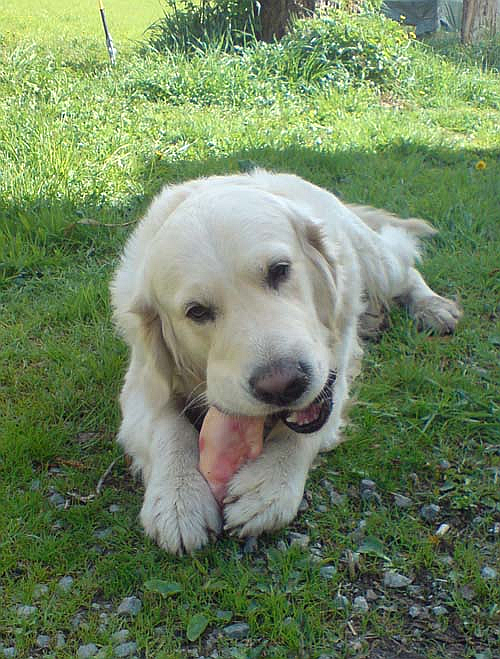

In [22]:
img_sharp = img.filter(ImageFilter.SHARPEN)
img_sharp

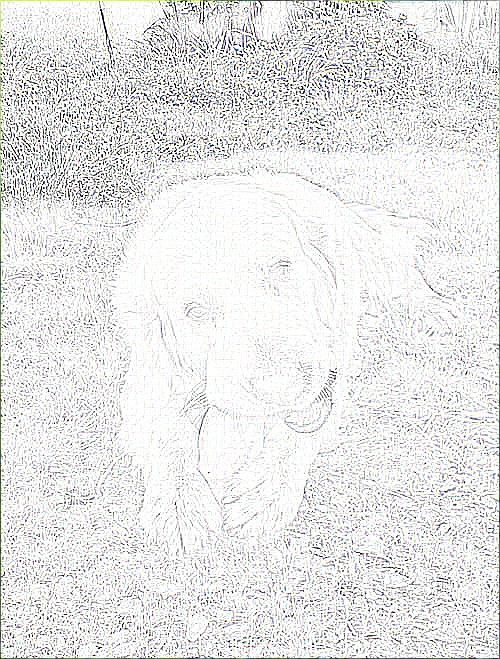

In [23]:
img_contour = img.filter(ImageFilter.CONTOUR)
img_contour

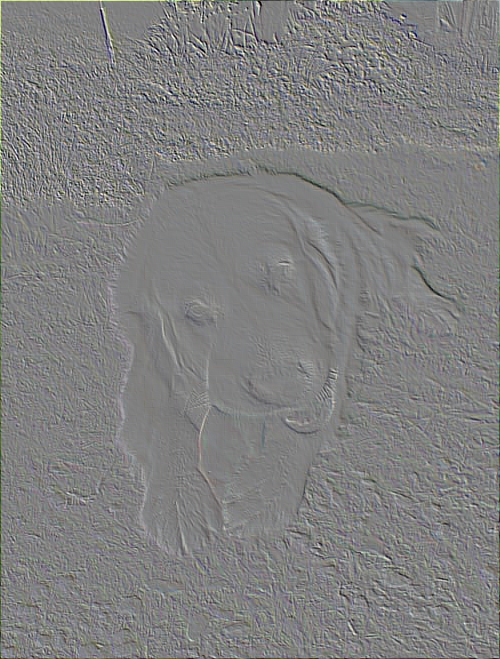

In [24]:
img_emboss = img.filter(ImageFilter.EMBOSS)
img_emboss

Convert to other formats

In [25]:
import os

source_file = "dog.jpg"
output_dir = "conversions"

# 1. Create a subdirectory named 'conversions'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# 2. Define a list of supported formats/extensions
# Note: Not all extensions are compatible with every image mode
formats = ["png", "jpg", "webp", "bmp", "tiff", "gif", "pdf"]

try:
    # Load the source image
    img = Image.open(source_file)
    
    # Convert to RGB to ensure compatibility with all formats (especially JPG and PDF)
    # This removes transparency but prevents errors.
    img_converted = img.convert("RGB")

    # 3. Iterate through the list and save files
    for ext in formats:
        filename = f"converted.{ext}"
        filepath = os.path.join(output_dir, filename)
        
        try:
            # Save the image in the specified format
            # Pillow usually infers the format from the extension
            img_converted.save(filepath)
            print(f"Successfully saved: {filepath}")
        except Exception as e:
            print(f"Could not save to {ext}: {e}")

except FileNotFoundError:
    print(f"Error: Source file '{source_file}' not found.")
except Exception as e:
    print(f"An error occurred: {e}")


Successfully saved: conversions\converted.png
Successfully saved: conversions\converted.jpg
Successfully saved: conversions\converted.webp
Successfully saved: conversions\converted.bmp
Successfully saved: conversions\converted.tiff
Successfully saved: conversions\converted.gif
Successfully saved: conversions\converted.pdf
